<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 11</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Interprétabilité et explicabilité des modèles d'apprentissage</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : le dispositif expérimental commun, fondé sur le jeu de données <i>Titanic</i> et un perceptron multicouche de `scikit-learn`, puis six méthodes d'explicabilité (importance par permutation, dépendance partielle, LIME, SHAP avec calcul manuel des valeurs de Shapley puis `KernelExplainer`, LRP et contrefactuels). Les cellules doivent être exécutées séquentiellement, car toutes les méthodes réutilisent le modèle et les données du dispositif commun.

**Bibliothèques requises** : `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn` (≥ 1.6), `lime` et `shap`. Ce carnet ne dépend ni de Keras ni de TensorFlow : le modèle est un `MLPClassifier` de `scikit-learn`.  
**Installation complémentaire** : LIME et SHAP s'installent avec `pip install lime shap`.  
**Données externes** : le jeu de données `titanic` est chargé avec `seaborn` ; une connexion Internet peut être nécessaire lors de son premier chargement.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration. La cellule SHAP fondée sur `KernelExplainer` (50 observations × 200 échantillons) est la plus longue à exécuter, soit environ une à deux minutes.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'lime', 'shap')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT, BLEU, MAGENTA = '#482878', '#21918c', '#5ec962', '#3b528b', '#bf00bf'
BORD    = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b', MAGENTA: '#8a008a'}
PALETTE = [VIOLET, SARCELLE, VERT, BLEU, MAGENTA]

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
seaborn            0.13.2
scikit-learn       1.9.0
lime               0.2.0.1
shap               0.52.0


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.1 : Lecture et préparation de données</h3>

In [3]:
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

df = sns.load_dataset('titanic')
features = ['pclass', 'sex', 'age', 'fare', 'sibsp', 'parch', 'embarked']
target = 'survived'
df = df[features + [target]].copy()

X, y = df[features].copy(), df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputation apprise uniquement sur l'ensemble d'entraînement
imputeur_age = SimpleImputer(strategy='median')
X_train['age'] = imputeur_age.fit_transform(X_train[['age']]).ravel()
X_test['age']  = imputeur_age.transform(X_test[['age']]).ravel()

imputeur_embarked = SimpleImputer(strategy='most_frequent')
X_train['embarked'] = imputeur_embarked.fit_transform(X_train[['embarked']]).ravel()
X_test['embarked']  = imputeur_embarked.transform(X_test[['embarked']]).ravel()

# Encodage : sex -> 0 = female, 1 = male ;
# embarked -> 0 = C, 1 = Q, 2 = S
variables_cat = ['sex', 'embarked']
encodeur = OrdinalEncoder()
X_train[variables_cat] = encodeur.fit_transform(X_train[variables_cat])
X_test[variables_cat]  = encodeur.transform(X_test[variables_cat])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.2 : Entraînement d'un perceptron multicouche avec scikit-learn</h3>

In [4]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(64, 32, 16),
                      activation='relu', solver='adam',
                      batch_size=16, max_iter=300,
                      early_stopping=True, random_state=42)
model.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",16
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the 

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.3 : Évaluation du modèle sur l'ensemble de test</h3>

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix

proba_test = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (proba_test >= 0.5).astype(int)
exactitude = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# --- Affichage ---
L = 40
print("=" * L)
print("Perceptron multicouche (MLP) : Titanic")
print("=" * L)
print(f"Exactitude (test) : {exactitude:.3f}")
print("-" * L)
print("Matrice de confusion :")
print(cm)
print("=" * L)

Perceptron multicouche (MLP) : Titanic
Exactitude (test) : 0.821
----------------------------------------
Matrice de confusion :
[[95 10]
 [22 52]]


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.4 : Importance par permutation, implémentée manuellement (10 répétitions par variable)</h3>

In [6]:
rng = np.random.default_rng(42)
importances = {}
ecarts_types = {}

for j, nom in enumerate(features):
    baisses = []
    for _ in range(10):
        X_perm = X_test_scaled.copy()
        X_perm[:, j] = rng.permutation(X_perm[:, j])

        proba_perm = model.predict_proba(X_perm)[:, 1]
        pred_perm = (proba_perm >= 0.5).astype(int)

        exactitude_perm = accuracy_score(y_test, pred_perm)
        baisses.append(exactitude - exactitude_perm)

    importances[nom] = np.mean(baisses)
    ecarts_types[nom] = np.std(baisses)

imp = pd.Series(importances).sort_values(ascending=False)

# --- Affichage ---
titre = "Importance par permutation (Titanic)"
L = max(30, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Variable':<15}{'Baisse moyenne'}")
print("-" * L)
for nom, val in imp.items():
    print(f"{nom:<15}{val:.4f}")

print("=" * L)

Importance par permutation (Titanic)
Variable       Baisse moyenne
------------------------------------
sex            0.1804
pclass         0.0330
age            0.0318
embarked       0.0307
sibsp          0.0196
parch          0.0184
fare           0.0011


<h3><span style="font-size: 30px">&#127924;</span> Figure : Importance par permutation des sept variables du modèle <i>Titanic</i></h3>

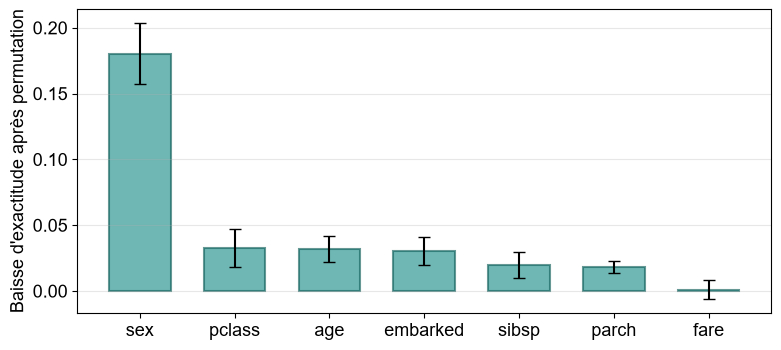

In [7]:
# Figure Fig_Chap11_permutation : baisse moyenne d'exactitude (10 permutations)
ordre = list(imp.index)
moy = [importances[nom] for nom in ordre]
ect = [ecarts_types[nom] for nom in ordre]

fig, ax = plt.subplots(figsize=(8, 3.7))

ax.bar(range(len(ordre)), moy, yerr=ect, capsize=4, color=SARCELLE,
       edgecolor=BORD[SARCELLE], linewidth=1.5, alpha=0.65, width=0.65)
ax.set_xticks(range(len(ordre)))
ax.set_xticklabels(ordre)
ax.set_ylabel("Baisse d'exactitude après permutation")
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='both', which='major')
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap11_permutation')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.5 : Calcul manuel de la dépendance partielle d'une variable</h3>

In [8]:
def dependance_partielle(j, grille):
    moyennes = []
    for v in grille:
        X_mod = X_test_scaled.copy()
        X_mod[:, j] = (v - scaler.mean_[j]) / scaler.scale_[j]
        moyennes.append(model.predict_proba(X_mod)[:, 1].mean())
    return np.array(moyennes)

resultats = []
for nom, grille in [('age', np.linspace(1, 70, 25)),
                    ('fare', np.linspace(0, 250, 25)),
                    ('pclass', np.array([1, 2, 3]))]:
    pd_vals = dependance_partielle(features.index(nom), grille)
    resultats.append((nom, pd_vals.min(), pd_vals.max()))

# --- Affichage ---
titre = "Dépendance partielle (PDP)"
L = max(30, len(titre))
print("=" * L)
print(titre)
print("=" * L)
print(f"{'Variable':<12}{'min':<10}{'max'}")
print("-" * L)
for nom, mn, mx in resultats:
    print(f"{nom:<12}{mn:<10.3f}{mx:.3f}")
print("=" * L)

Dépendance partielle (PDP)
Variable    min       max
------------------------------
age         0.387     0.571
fare        0.391     0.529
pclass      0.306     0.546


<h3><span style="font-size: 30px">&#127924;</span> Figure : Graphiques de dépendance partielle des variables <code>age</code>, <code>fare</code> et <code>pclass</code></h3>

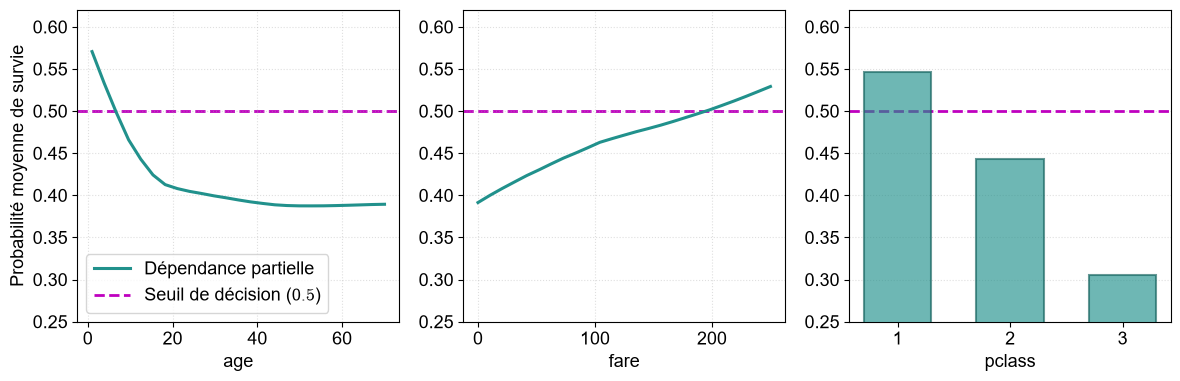

In [9]:
# Figure Fig_Chap11_pdp : trois courbes de dépendance partielle
grilles = {'age'    : np.linspace(1, 70, 25),
           'fare'   : np.linspace(0, 250, 25),
           'pclass' : np.array([1, 2, 3])}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (nom, grille) in zip(axes, grilles.items()):
    pd_vals = dependance_partielle(features.index(nom), grille)

    if nom == 'pclass':
        ax.set_axisbelow(True)
        ax.bar(grille, pd_vals, color=SARCELLE, edgecolor=BORD[SARCELLE],
               linewidth=1.5, width=0.6, alpha=0.65, zorder=3,
               label='Dépendance partielle')
        ax.set_xticks([1, 2, 3])
        ax.grid(axis='y', alpha=0.4, linestyle=':')
    else:
        ax.plot(grille, pd_vals, color=SARCELLE, linewidth=2.2, zorder=3,
                label='Dépendance partielle')
        ax.grid(alpha=0.4, linestyle=':')
        
    # Seuil de décision
    ax.axhline(0.5, color=MAGENTA, linestyle='--', linewidth=2, zorder=1,
               label='Seuil de décision ($0.5$)')

    ax.set_xlabel(nom)
    ax.set_ylim(0.25, 0.62)
    ax.tick_params(axis='both')

axes[0].set_ylabel('Probabilité moyenne de survie')
axes[0].legend(fontsize=13, loc='lower left')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap11_pdp')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.6 : Dépendance partielle à deux variables</h3>

In [10]:
def dependance_partielle_2d(j1, grille1, j2, valeur2):
    moyennes = []
    for v in grille1:
        X_mod = X_test_scaled.copy()
        X_mod[:, j1] = (v - scaler.mean_[j1]) / scaler.scale_[j1]
        X_mod[:, j2] = (valeur2 - scaler.mean_[j2]) / scaler.scale_[j2]
        moyennes.append(model.predict_proba(X_mod)[:, 1].mean())
    return np.array(moyennes)

ages = np.linspace(1, 70, 25)
j_age, j_sex = features.index('age'), features.index('sex')
pdp_femmes = dependance_partielle_2d(j_age, ages, j_sex, 0)
pdp_hommes = dependance_partielle_2d(j_age, ages, j_sex, 1)
ecart_max = max(abs(pdp_femmes - pdp_hommes))

# --- Affichage ---
titre = "PDP 2D : âge × sexe (Titanic)"
L = max(45, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Sexe':<10}{'À 1 an':<10}{'À 70 ans'}")
print("-" * L)
print(f"{'Femmes':<10}{pdp_femmes[0]:<10.3f}{pdp_femmes[-1]:.3f}")
print(f"{'Hommes':<10}{pdp_hommes[0]:<10.3f}{pdp_hommes[-1]:.3f}")
print("-" * L)
print(f"Écart maximal (toutes valeurs d'âge) : {ecart_max:.3f}")
print("=" * L)

PDP 2D : âge × sexe (Titanic)
Sexe      À 1 an    À 70 ans
---------------------------------------------
Femmes    0.727     0.775
Hommes    0.482     0.139
---------------------------------------------
Écart maximal (toutes valeurs d'âge) : 0.638


<h3><span style="font-size: 30px">&#127924;</span> Figure : Dépendance partielle croisée de l'âge et du sexe</h3>

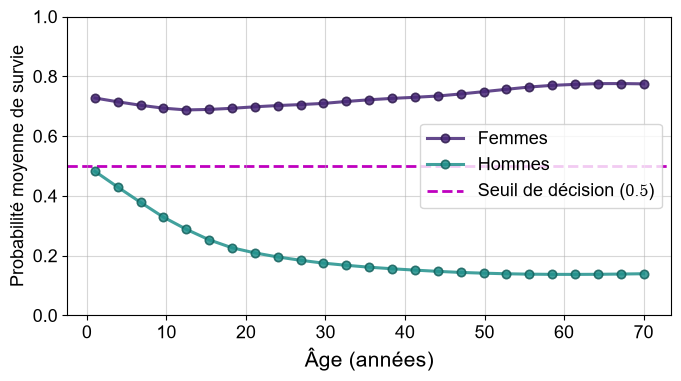

In [11]:
# Figure Fig_Chap11_pdp2d : effet de l'âge selon le sexe
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(ages, pdp_femmes, color=VIOLET, linewidth=2.2, marker='o',
        markersize=6, markeredgecolor=BORD[VIOLET], markeredgewidth=1.2,
        alpha=0.85, label='Femmes', zorder=3)
ax.plot(ages, pdp_hommes, color=SARCELLE, linewidth=2.2, marker='o',
        markersize=6, markeredgecolor=BORD[SARCELLE], markeredgewidth=1.2,
        alpha=0.85, label='Hommes', zorder=3)
ax.axhline(0.5, color=MAGENTA, linestyle='--', linewidth=2,
           label='Seuil de décision ($0.5$)', zorder=1)
ax.set_xlabel('Âge (années)', fontsize=15)
ax.set_ylabel('Probabilité moyenne de survie')
ax.tick_params(axis='both', which='major')
ax.set_ylim(0, 1)
ax.grid(alpha=0.5, zorder=0)
ax.legend()
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap11_pdp2d')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.7 : Explication locale de la prédiction d'un passager avec LIME</h3>

In [12]:
from lime.lime_tabular import LimeTabularExplainer

explicateur = LimeTabularExplainer(
    X_train_scaled, feature_names=features,
    class_names=['non-survie', 'survie'],
    mode='classification', random_state=42)

exp = explicateur.explain_instance(
    X_test_scaled[0], model.predict_proba, num_features=5)
p_survie = model.predict_proba(X_test_scaled[0:1])[0, 1]

# --- Affichage ---
titre = "Explication LIME (observation 0, Titanic)"
L = max(40, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"P(survie) = {p_survie:.3f}")
print("-" * L)
print(f"{'Poids':<10}{'Règle'}")
for regle, poids in exp.as_list():
    print(f"{poids:+.3f}     {regle}")
print("=" * L)

Explication LIME (observation 0, Titanic)
P(survie) = 0.236
-----------------------------------------
Poids     Règle
-0.182     -0.40 < pclass <= 0.81
-0.154     -1.38 < sex <= 0.72
+0.076     embarked <= -0.73
+0.030     parch > -0.48
-0.028     -0.55 < age <= -0.09


<h3><span style="font-size: 30px">&#127924;</span> Figure : Explications LIME de deux passagers de l'ensemble de test</h3>

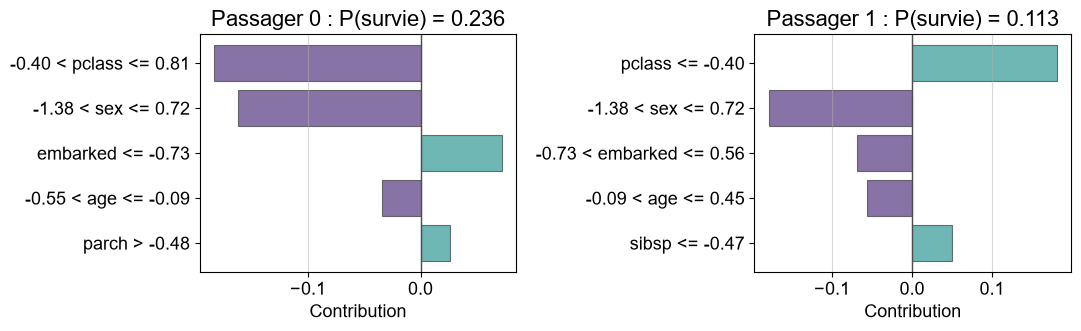

In [13]:
# Figure Fig_Chap11_lime : contributions LIME pour deux passagers
def exp_lime(i):
    e = explicateur.explain_instance(X_test_scaled[i], model.predict_proba, num_features=5)
    return e.as_list(), model.predict_proba(X_test_scaled[i:i+1])[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, i in zip(axes, [0, 1]):
    regles, p = exp_lime(i)
    noms = [r for r, _ in regles][::-1]
    vals = [v for _, v in regles][::-1]
    couls = [SARCELLE if v > 0 else VIOLET for v in vals]
    ax.barh(range(len(vals)), vals, color=couls, edgecolor='0.2',
            linewidth=0.8, alpha=0.65)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(noms)
    ax.axvline(0, color='0.3', linewidth=1)
    ax.set_title(f"Passager {i} : P(survie) = {p:.3f}")
    ax.tick_params(axis='both', which='major')
    ax.set_xlabel('Contribution')
    ax.grid(axis='x', alpha=0.5)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap11_lime')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.8 : Calcul exact des valeurs de Shapley par énumération des ordres d'arrivée</h3>

In [14]:
from itertools import combinations, permutations
from sklearn.linear_model import LogisticRegression

def v(S):
    if not S:
        classe = int(y_train.mean() >= 0.5)
        return accuracy_score(y_test, np.full(len(y_test), classe))
    cols = [features.index(c) for c in S]
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_scaled[:, cols], y_train)
    return accuracy_score(y_test, clf.predict(X_test_scaled[:, cols]))

trio = ['sex', 'pclass', 'age']

# Les 8 coalitions, puis la moyenne sur les 6 ordres d'arrivée
valeurs = {S: v(S) for k in range(4) for S in combinations(trio, k)}

phi = {c: 0.0 for c in trio}
for ordre in permutations(trio):
    S = []
    for c in ordre:
        avant = valeurs[tuple(sorted(S, key=trio.index))]
        S.append(c)
        apres = valeurs[tuple(sorted(S, key=trio.index))]
        phi[c] += (apres - avant) / 6
somme = sum(phi.values())
ecart_total = valeurs[('sex', 'pclass', 'age')] - valeurs[()]

# --- Affichage ---
titre = "Valeurs de Shapley (sex, pclass, age)"
L = max(30, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Variable':<18}{'φ'}")
print("-" * L)
for c in trio:
    print(f"{c:<18}{phi[c]:+.4f}")
print("-" * L)
print(f"{'Somme':<18}{somme:+.4f}")
print(f"{'v(N) - v(∅)':<18}{ecart_total:+.4f}")
print("=" * L)

Valeurs de Shapley (sex, pclass, age)
Variable          φ
-------------------------------------
sex               +0.1276
pclass            +0.0745
age               +0.0158
-------------------------------------
Somme             +0.2179
v(N) - v(∅)       +0.2179


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.9 : Valeurs SHAP du perceptron multicouche et importance globale par agrégation</h3>

In [15]:
import shap

np.random.seed(42)
fond = shap.sample(X_train_scaled, 100, random_state=42)
explicateur_shap = shap.KernelExplainer(
    lambda z: model.predict_proba(z)[:, 1], fond)

valeurs_shap = explicateur_shap.shap_values(
    X_test_scaled[:50], nsamples=200, silent=True)

importance = pd.Series(np.abs(valeurs_shap).mean(axis=0),
                       index=features).sort_values(ascending=False)

# --- Affichage ---
titre = "Importance SHAP moyenne (Titanic)"
L = max(30, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Variable':<15}{'|SHAP| moyen'}")
print("-" * L)
for nom, val in importance.items():
    print(f"{nom:<15}{val:.4f}")
print("=" * L)

Importance SHAP moyenne (Titanic)
Variable       |SHAP| moyen
---------------------------------
sex            0.2244
pclass         0.0979
embarked       0.0324
sibsp          0.0278
age            0.0210
parch          0.0167
fare           0.0153


<h3><span style="font-size: 30px">&#127924;</span> Figure : Importance globale SHAP (valeur absolue moyenne sur 50 observations)</h3>

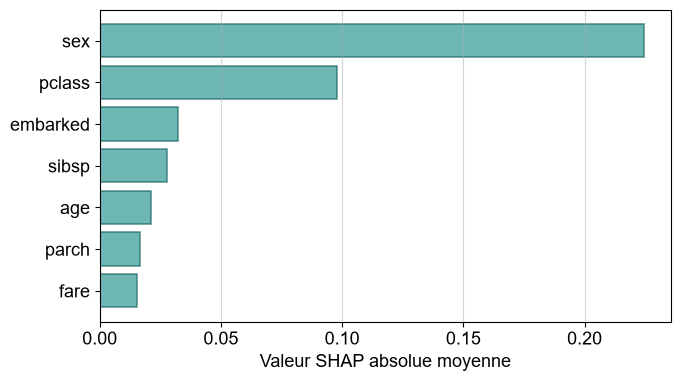

In [16]:
# Figure Fig_Chap11_shap_importance
imp_shap = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(range(len(imp_shap)), imp_shap.values, color=SARCELLE,
        edgecolor=BORD[SARCELLE], linewidth=1.2, alpha=0.65)
ax.set_yticks(range(len(imp_shap)))
ax.set_yticklabels(imp_shap.index)
ax.set_xlabel('Valeur SHAP absolue moyenne')
ax.tick_params(axis='both', which='major')
ax.grid(axis='x', alpha=0.5)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap11_shap_importance')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.10 : Valeurs SHAP locales d'un passager et vérification de l'efficacité</h3>

In [17]:
valeurs_locales = explicateur_shap.shap_values(
    X_test_scaled[0], nsamples=200, silent=True)

base = explicateur_shap.expected_value
somme_phi = valeurs_locales.sum()
prediction = model.predict_proba(X_test_scaled[0:1])[0, 1]
classement = sorted(zip(features, valeurs_locales), key=lambda t: -abs(t[1]))

# --- Affichage ---
titre = "Explication SHAP locale (observation 0)"
L = max(30, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Valeur de base E[f]':<22}{base:.4f}")
print(f"{'Somme des φⱼ':<22}{somme_phi:+.4f}")
print(f"{'Prédiction f(x)':<22}{prediction:.4f}")
print("-" * L)
for nom, phi in classement:
    print(f"{nom:<12}{phi:+.4f}")
print("=" * L)

Explication SHAP locale (observation 0)
Valeur de base E[f]   0.3872
Somme des φⱼ          -0.1510
Prédiction f(x)       0.2362
---------------------------------------
sex         -0.1656
embarked    +0.0731
pclass      -0.0717
parch       +0.0354
sibsp       -0.0130
age         -0.0097
fare        +0.0006


<h3><span style="font-size: 30px">&#127924;</span> Figure : Contributions LIME et SHAP pour le même passager</h3>

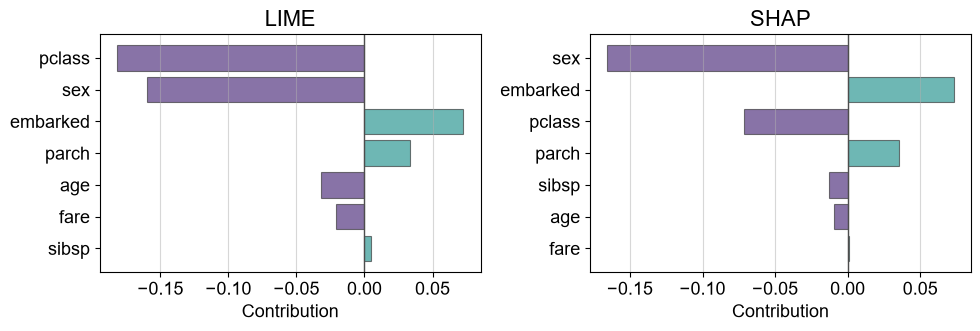

In [18]:
# Figure Fig_Chap11_lime_shap : les deux explications locales côte à côte
exp0 = explicateur.explain_instance(X_test_scaled[0], model.predict_proba,
                                    num_features=7)
poids_lime = dict(exp0.as_map()[1])          # indices de variables -> poids
contrib_lime = [poids_lime.get(j, 0.0) for j in range(len(features))]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, vals, titre in zip(axes, [contrib_lime, list(valeurs_locales)],
                           ['LIME', 'SHAP']):
    ordre_v = np.argsort(np.abs(vals))
    noms = [features[j] for j in ordre_v]
    v = [vals[j] for j in ordre_v]
    couls = [SARCELLE if x > 0 else VIOLET for x in v]
    ax.barh(range(len(v)), v, color=couls,
            edgecolor='0.2', linewidth=0.8, alpha=0.65)
    ax.set_yticks(range(len(v)))
    ax.set_yticklabels(noms)
    ax.tick_params(axis='both', which='major')
    ax.axvline(0, color='0.3', linewidth=1)
    ax.set_title(titre)
    ax.set_xlabel('Contribution')
    ax.grid(axis='x', alpha=0.5)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap11_lime_shap')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.11 : Implémentation manuelle de la règle ε de LRP et vérification de la conservation</h3>

In [19]:
def lrp(x, eps=1e-6):
    # Propagation avant : activations et logit de sortie
    activations = [x]
    a = x
    for k in range(len(poids)):
        z = a @ poids[k] + biais[k]
        if k < len(poids) - 1:
            a = np.maximum(z, 0)
        else:
            logit = z
            a = 1 / (1 + np.exp(-z))
        activations.append(a)

    # Rétropropagation de la pertinence,
    # Règle epsilon, à partir du logit de sortie
    R = logit.copy()
    for k in range(len(poids) - 1, -1, -1):
        a_prec = activations[k]
        z = a_prec @ poids[k] + biais[k]
        z = z + eps * np.where(z >= 0, 1, -1)
        R = a_prec * ((R / z) @ poids[k].T)

    return R, logit, activations[-1]

poids = model.coefs_
biais = model.intercepts_
R, logit, sortie = lrp(X_test_scaled[0:1])
somme_R = R.sum()
classement = sorted(zip(features, R[0]), key=lambda t: -abs(t[1]))

# --- Affichage ---
titre = "LRP : pertinence locale (observation 0)"
L = max(30, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'P(survie | x)':<22}{sortie[0, 0]:.4f}")
print(f"{'Logit z(x)':<22}{logit[0, 0]:+.4f}")
print(f"{'Somme des Rⱼ':<22}{somme_R:+.4f}")
print("-" * L)
for nom, r in classement:
    print(f"{nom:<15}{r:+.4f}")
print("=" * L)

LRP : pertinence locale (observation 0)
P(survie | x)         0.2362
Logit z(x)            -1.1737
Somme des Rⱼ          -0.5069
---------------------------------------
sex            -0.5985
pclass         -0.2105
embarked       +0.1853
parch          +0.1547
sibsp          -0.1045
age            +0.0505
fare           +0.0163


<h3><span style="font-size: 30px">&#127924;</span> Figure : Importance globale LRP (pertinence absolue moyenne sur l'ensemble de test)</h3>

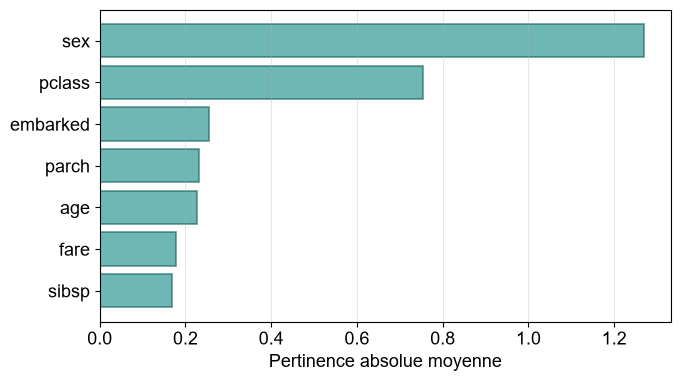

In [20]:
# Figure Fig_Chap11_lrp_importance : agrégation des pertinences absolues
R_tout, _, _ = lrp(X_test_scaled)
imp_lrp = pd.Series(np.abs(R_tout).mean(axis=0),
                    index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(range(len(imp_lrp)), imp_lrp.values, color=SARCELLE,
        edgecolor=BORD[SARCELLE], linewidth=1.2, alpha=0.65)
ax.set_yticks(range(len(imp_lrp)))
ax.tick_params(axis='both', which='major')
ax.set_yticklabels(imp_lrp.index)
ax.set_xlabel('Pertinence absolue moyenne')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap11_lrp_importance')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 11.12 : Recherche de contrefactuels par modification d'une variable à la fois</h3>

In [21]:
x_orig = X_test.iloc[0].copy()
candidats = {'pclass': [1, 2], 'sex': [0], 'age': [5, 15], 'fare': [80, 150]}

resultats = []
for var, valeurs_c in candidats.items():
    for v_ in valeurs_c:
        x_mod = x_orig.copy()
        x_mod[var] = v_
        z = scaler.transform(pd.DataFrame([x_mod], columns=features))
        resultats.append((var, v_, model.predict_proba(z)[0, 1]))
resultats = sorted(resultats, key=lambda t: -t[2])

# --- Affichage ---
titre = "Explications contrefactuelles (observation 0)"
L = max(30, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Variable':<12}{'Valeur':<10}{'P(survie)'}")
print("-" * L)
for var, v_, p in resultats:
    bascule = "  <- bascule" if p >= 0.5 else ""
    print(f"{var:<12}{v_:<10.0f}{p:.3f}{bascule}")
print("=" * L)

Explications contrefactuelles (observation 0)
Variable    Valeur    P(survie)
---------------------------------------------
sex         0         0.623  <- bascule
age         5         0.426
pclass      1         0.370
age         15        0.313
pclass      2         0.277
fare        80        0.222
fare        150       0.196


<h3><span style="font-size: 30px">&#128187;</span> Complément : coût de calcul des six méthodes, mesuré par le nombre de lignes soumises au modèle et par le temps écoulé</h3>

In [22]:
import time

# --- Instrumentation ---
compteur = {'n': 0}
predire = model.predict_proba
def predict_proba_compte(Z):
    compteur['n'] += len(np.atleast_2d(Z))
    return predire(Z)
model.predict_proba = predict_proba_compte

def mesure(nom, fonction):
    compteur['n'] = 0
    t0 = time.perf_counter()
    fonction()
    duree = time.perf_counter() - t0
    return nom, compteur['n'], duree * 1000

def cout_permutation():
    generateur = np.random.default_rng(42)
    for j in range(len(features)):
        for _ in range(10):
            Z = X_test_scaled.copy()
            Z[:, j] = generateur.permutation(Z[:, j])
            model.predict_proba(Z)

def cout_pdp():
    for nom, grille in [('age', np.linspace(1, 70, 25)),
                        ('fare', np.linspace(0, 250, 25)),
                        ('pclass', np.array([1, 2, 3]))]:
        dependance_partielle(features.index(nom), grille)

def cout_contrefactuels():
    x0 = X_test.iloc[0].copy()
    for var, vals in {'pclass': [1, 2], 'sex': [0],
                      'age': [5, 15], 'fare': [80, 150]}.items():
        for v_ in vals:
            xm = x0.copy()
            xm[var] = v_
            model.predict_proba(scaler.transform(
                pd.DataFrame([xm], columns=features)))

# --- Calculs ---
resultats = [
    mesure("Importance par permutation (7 var, 10 rep.)", cout_permutation),
    mesure("Dépendance partielle (3 var, 25 points)", cout_pdp),
    mesure("LIME (1 observation)", lambda: explicateur.explain_instance(
        X_test_scaled[0], model.predict_proba, num_features=5)),
    mesure("SHAP local (1 observation)", lambda: explicateur_shap.shap_values(
        X_test_scaled[0], nsamples=200, silent=True)),
    mesure("SHAP global (50 observations)", lambda: explicateur_shap.shap_values(
        X_test_scaled[:50], nsamples=200, silent=True)),
    mesure("LRP (ensemble de test complet)", lambda: lrp(X_test_scaled)),
    mesure("Contrefactuels (7 modifications)", cout_contrefactuels),
]
model.predict_proba = predire      # rétablissement

# --- Affichage ---
L = 75
print("=" * L)
print("Coût computationnel des méthodes d'explicabilité")
print("=" * L)
print(f"{'Méthode':<46}{'Lignes':>10}{'Durée (ms)':>14}")
print("-" * L)
for nom, n, duree in resultats:
    print(f"{nom:<46}{n:>10d}{duree:>14.1f}")
print("=" * L)

Coût computationnel des méthodes d'explicabilité
Méthode                                           Lignes    Durée (ms)
---------------------------------------------------------------------------
Importance par permutation (7 var, 10 rep.)        12530          34.8
Dépendance partielle (3 var, 25 points)             9487          19.2
LIME (1 observation)                                5000          75.4
SHAP local (1 observation)                         12601           9.7
SHAP global (50 observations)                     630050         561.1
LRP (ensemble de test complet)                         0           0.5
Contrefactuels (7 modifications)                       7          11.6


<hr style='border-top:4px solid #1F77B4;'>